# 01 - MovieLens Exploratory Data Analysis

In [13]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")


project_root = find_project_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data.common import (
    MOVIES_COLUMNS,
    RATINGS_COLUMNS,
    USERS_COLUMNS,
    canonicalize_dataframe_columns,
    load_table,
    validate_input_files,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [14]:
def load_movie_lens_tables(project_root: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, str]:
    interim_dir = project_root / "data" / "interim"
    raw_dir = project_root / "data" / "raw"

    cleaned_paths = {
        "ratings": interim_dir / "ratings_cleaned.csv",
        "movies": interim_dir / "movies_cleaned.csv",
        "users": interim_dir / "users_cleaned.csv",
    }

    if all(path.exists() for path in cleaned_paths.values()):
        ratings_df = canonicalize_dataframe_columns(pd.read_csv(cleaned_paths["ratings"]))
        movies_df = canonicalize_dataframe_columns(pd.read_csv(cleaned_paths["movies"]))
        users_df = canonicalize_dataframe_columns(pd.read_csv(cleaned_paths["users"]))
        source_label = "cleaned CSV files from data/interim"
    else:
        validate_input_files(raw_dir)
        ratings_df = canonicalize_dataframe_columns(load_table(raw_dir / "ratings.dat", RATINGS_COLUMNS))
        movies_df = canonicalize_dataframe_columns(load_table(raw_dir / "movies.dat", MOVIES_COLUMNS))
        users_df = canonicalize_dataframe_columns(load_table(raw_dir / "users.dat", USERS_COLUMNS))
        source_label = "raw DAT files from data/raw"

    return ratings_df, movies_df, users_df, source_label


project_root = find_project_root(Path.cwd())
ratings, movies, users, source_label = load_movie_lens_tables(project_root)

required_columns = {
    "ratings": {"user_id", "movie_id", "rating", "timestamp"},
    "movies": {"movie_id", "title", "genres"},
    "users": {"user_id"},
}

for table_name, expected_columns in required_columns.items():
    table = {"ratings": ratings, "movies": movies, "users": users}[table_name]
    missing_columns = expected_columns - set(table.columns)
    if missing_columns:
        raise ValueError(f"{table_name} is missing columns: {sorted(missing_columns)}")

print(f"Loaded data source: {source_label}")
print(f"ratings: {ratings.shape}")
print(f"movies: {movies.shape}")
print(f"users: {users.shape}")

Loaded data source: cleaned CSV files from data/interim
ratings: (1000209, 4)
movies: (3883, 3)
users: (6040, 5)


## 1. Dataset Overview (Users, Movies, Ratings)

This section establishes the recommendation problem size: number of users, movies, ratings, and unique user-movie interactions. These metrics are the foundation for interpreting sparsity later.

In [15]:
num_users = users["user_id"].nunique()
num_movies = movies["movie_id"].nunique()
num_ratings = len(ratings)

num_unique_user_in_ratings = ratings["user_id"].nunique()
num_unique_movie_in_ratings = ratings["movie_id"].nunique()
num_unique_interactions = ratings[["user_id", "movie_id"]].drop_duplicates().shape[0]

overview = pd.DataFrame(
    {
        "metric": [
            "Number of users (users table)",
            "Number of movies (movies table)",
            "Number of ratings (ratings table)",
            "Unique users appearing in ratings",
            "Unique movies appearing in ratings",
            "Unique user-movie pairs",
        ],
        "value": [
            num_users,
            num_movies,
            num_ratings,
            num_unique_user_in_ratings,
            num_unique_movie_in_ratings,
            num_unique_interactions,
        ],
    }
)

display(overview)

print(f"User-item matrix shape: ({num_users:,}, {num_movies:,})")
print(f"Observed interactions: {num_ratings:,}")

,metric,value
0,Number of users (users table),6040
1,Number of movies (movies table),3883
2,Number of ratings (ratings table),1000209
3,Unique users appearing in ratings,6040
4,Unique movies appearing in ratings,3706
5,Unique user-movie pairs,1000209


User-item matrix shape: (6,040, 3,883)
Observed interactions: 1,000,209


## 2. Rating Distribution

This section answers whether users tend to give high or low ratings and how skewed the rating distribution is.

,rating,count,percentage
0,1,56174,5.616226
1,2,107557,10.753453
2,3,261197,26.114242
3,4,348971,34.889808
4,5,226310,22.626271


Mean rating: 3.582
Median rating: 4.000
Std rating: 1.117


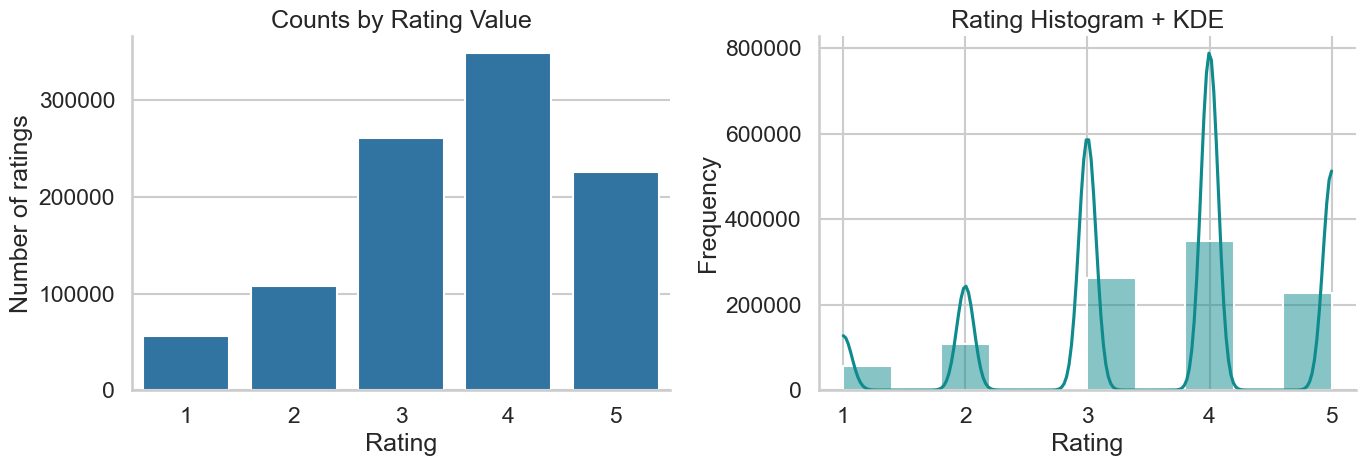

In [16]:
rating_dist = (
    ratings["rating"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)
rating_dist["percentage"] = rating_dist["count"] / num_ratings * 100

display(rating_dist)

mean_rating = ratings["rating"].mean()
median_rating = ratings["rating"].median()
std_rating = ratings["rating"].std()

print(f"Mean rating: {mean_rating:.3f}")
print(f"Median rating: {median_rating:.3f}")
print(f"Std rating: {std_rating:.3f}")

plot_df = rating_dist[rating_dist["rating"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=plot_df, x="rating", y="count", color="#1f77b4", ax=axes[0])
axes[0].set_title("Counts by Rating Value")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of ratings")

sns.histplot(ratings["rating"], bins=10, kde=True, color="#0f8b8d", ax=axes[1])
axes[1].set_title("Rating Histogram + KDE")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 3. Ratings per User and per Movie

This section measures user activity and movie popularity, which are key signals for cold-start and long-tail analysis. The results show that both distributions are highly right-skewed: most users provide only a limited number of ratings, and most movies receive relatively few ratings, while a small subset of users and movies accounts for a large share of interactions. This pattern indicates data sparsity and a clear long-tail structure, which are common characteristics of recommendation datasets.

,ratings_per_user
count,6040.000000
mean,165.597517
std,192.747029
min,20.000000
10%,27.000000
25%,44.000000
50%,96.000000
75%,208.000000
90%,400.000000
95%,556.000000


,ratings_per_movie
count,3706.000000
mean,269.889099
std,384.047838
min,1.000000
10%,7.000000
25%,33.000000
50%,123.500000
75%,350.000000
90%,729.500000
95%,1051.500000


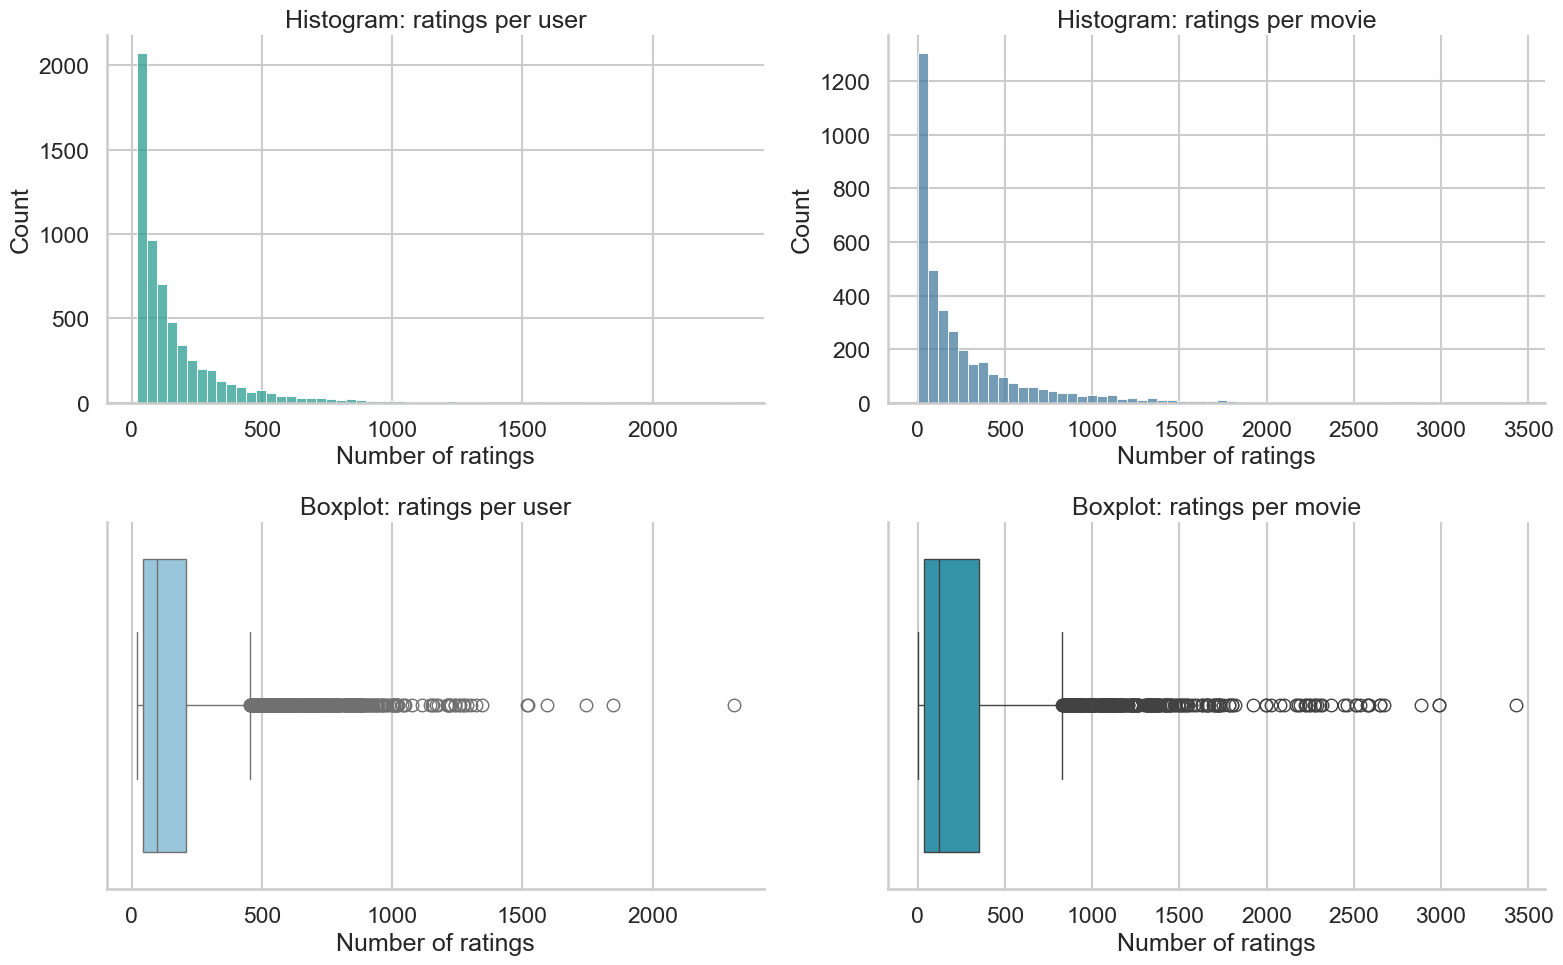

In [17]:
ratings_per_user = ratings.groupby("user_id").size().rename("rating_count").sort_values(ascending=False)
ratings_per_movie = ratings.groupby("movie_id").size().rename("rating_count").sort_values(ascending=False)

user_stats = ratings_per_user.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("ratings_per_user")
movie_stats = ratings_per_movie.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("ratings_per_movie")

display(user_stats)
display(movie_stats)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(ratings_per_user, bins=60, ax=axes[0, 0], color="#2a9d8f")
axes[0, 0].set_title("Histogram: ratings per user")
axes[0, 0].set_xlabel("Number of ratings")

sns.histplot(ratings_per_movie, bins=60, ax=axes[0, 1], color="#457b9d")
axes[0, 1].set_title("Histogram: ratings per movie")
axes[0, 1].set_xlabel("Number of ratings")

sns.boxplot(x=ratings_per_user.values, ax=axes[1, 0], color="#8ecae6")
axes[1, 0].set_title("Boxplot: ratings per user")
axes[1, 0].set_xlabel("Number of ratings")

sns.boxplot(x=ratings_per_movie.values, ax=axes[1, 1], color="#219ebc")
axes[1, 1].set_title("Boxplot: ratings per movie")
axes[1, 1].set_xlabel("Number of ratings")

plt.tight_layout()
plt.show()

## 4. Top Movies by Rating Count

This section lists the most frequently rated movies to make the popularity "head" explicit. The results show that a small number of well-known titles attract a disproportionately large number of ratings, confirming the presence of strong popularity concentration in the dataset. This pattern is important for EDA because it highlights popularity bias: a few blockbuster movies dominate user interactions, while most other movies remain in the long tail with much lower visibility.

,movie_id,title,rating_count
2651,2858,American Beauty (1999),3428
253,260,Star Wars: Episode IV - A New Hope (1977),2991
1106,1196,Star Wars: Episode V - The Empire Strikes Back...,2990
1120,1210,Star Wars: Episode VI - Return of the Jedi (1983),2883
466,480,Jurassic Park (1993),2672
1848,2028,Saving Private Ryan (1998),2653
575,589,Terminator 2: Judgment Day (1991),2649
2374,2571,"Matrix, The (1999)",2590
1178,1270,Back to the Future (1985),2583
579,593,"Silence of the Lambs, The (1991)",2578


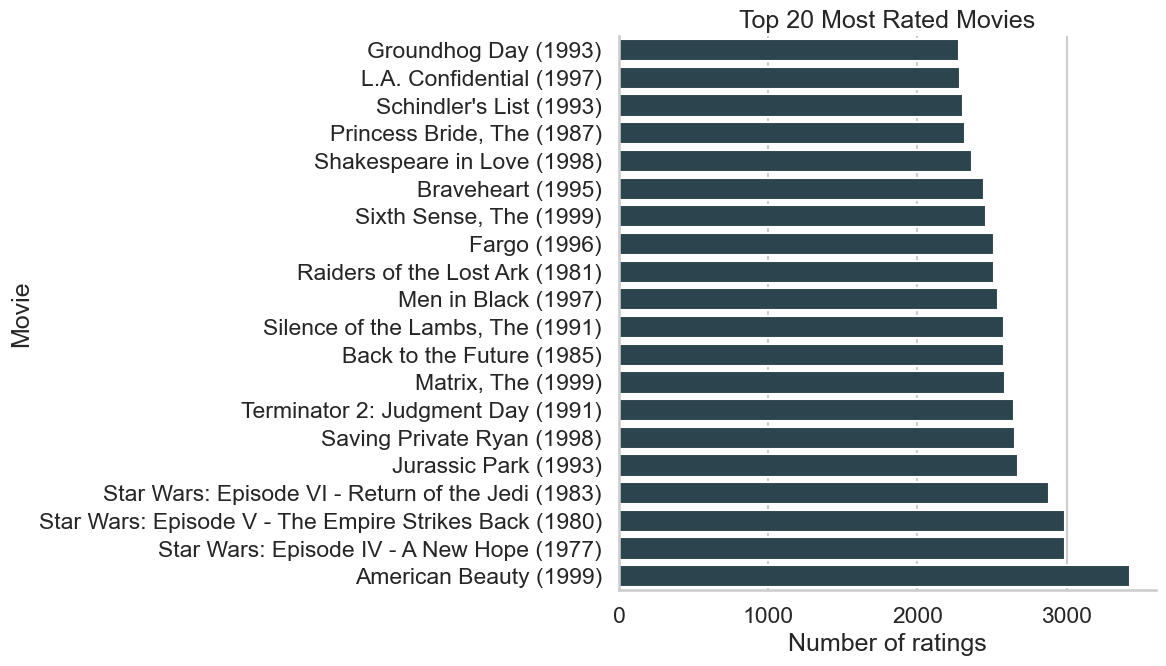

In [18]:
top_n = 20

top_movies = (
    ratings.groupby("movie_id")
    .size()
    .rename("rating_count")
    .reset_index()
    .merge(movies[["movie_id", "title"]], on="movie_id", how="left")
    .sort_values("rating_count", ascending=False)
    .head(top_n)
)

display(top_movies[["movie_id", "title", "rating_count"]])

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_movies.sort_values("rating_count", ascending=True),
    x="rating_count",
    y="title",
    color="#264653",
)
plt.title(f"Top {top_n} Most Rated Movies")
plt.xlabel("Number of ratings")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()

## 5. User-Item Sparsity and Long-Tail Distribution

This section measures matrix sparsity and long-tail concentration to reveal how sparse and imbalanced the interaction data is. These properties are central to recommendation modeling because they shape cold-start difficulty, popularity bias, and evaluation outcomes.

,metric,value
0,User-item matrix density,4.264680%
1,User-item matrix sparsity,95.735320%
2,Movie popularity Gini,0.634
3,User activity Gini,0.529
4,Top 1% movies share,8.91%
5,Top 5% movies share,28.38%
6,Top 10% movies share,44.45%
7,Top 20% movies share,65.21%
8,Top 1% users share,6.98%
9,Top 5% users share,23.93%


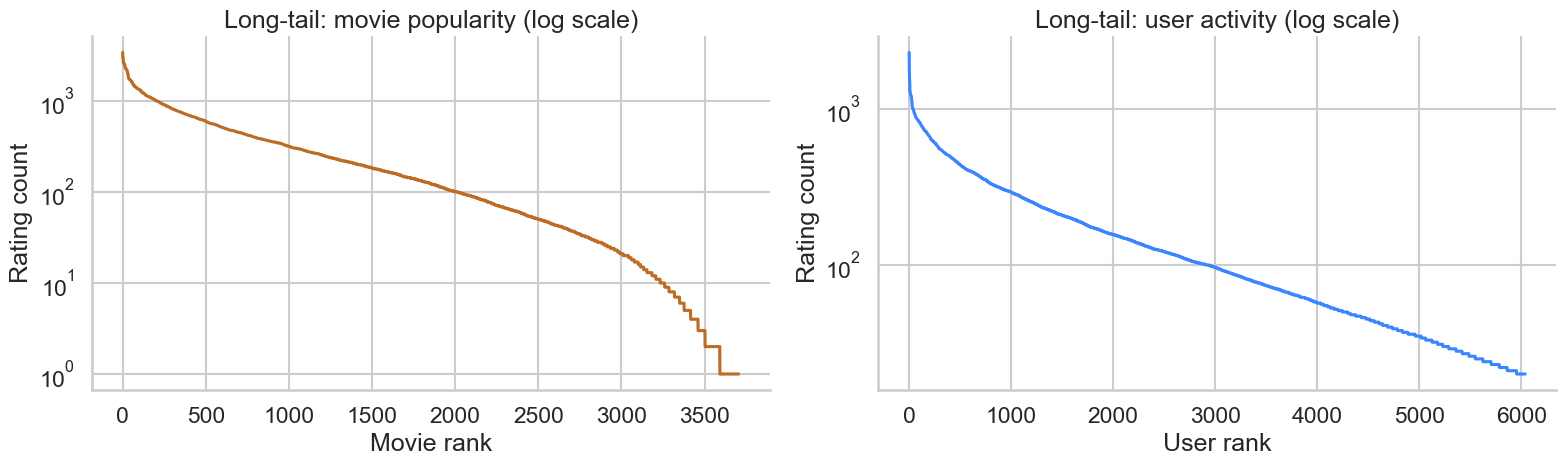

In [19]:
total_possible = num_users * num_movies
observed = num_ratings
density = observed / total_possible
sparsity = 1 - density

movie_counts_sorted = ratings_per_movie.sort_values(ascending=False)
user_counts_sorted = ratings_per_user.sort_values(ascending=False)


def gini(values: np.ndarray) -> float:
    arr = np.array(values, dtype=float)
    if arr.size == 0:
        return 0.0
    if np.min(arr) < 0:
        arr = arr - np.min(arr)
    if arr.sum() == 0:
        return 0.0
    arr = np.sort(arr)
    n = arr.size
    index = np.arange(1, n + 1)
    return float(np.sum((2 * index - n - 1) * arr) / (n * np.sum(arr)))


def head_share(sorted_counts: pd.Series, frac: float) -> float:
    k = int(np.ceil(frac * len(sorted_counts)))
    return sorted_counts.iloc[:k].sum() / sorted_counts.sum()


movie_head_1 = head_share(movie_counts_sorted, 0.01)
movie_head_5 = head_share(movie_counts_sorted, 0.05)
movie_head_10 = head_share(movie_counts_sorted, 0.10)
movie_head_20 = head_share(movie_counts_sorted, 0.20)

user_head_1 = head_share(user_counts_sorted, 0.01)
user_head_5 = head_share(user_counts_sorted, 0.05)
user_head_10 = head_share(user_counts_sorted, 0.10)
user_head_20 = head_share(user_counts_sorted, 0.20)

cold_start_user_ratio_1 = (ratings_per_user <= 1).mean()
cold_start_user_ratio_5 = (ratings_per_user <= 5).mean()
cold_start_movie_ratio_1 = (ratings_per_movie <= 1).mean()
cold_start_movie_ratio_5 = (ratings_per_movie <= 5).mean()

sparsity_summary = pd.DataFrame(
    {
        "metric": [
            "User-item matrix density",
            "User-item matrix sparsity",
            "Movie popularity Gini",
            "User activity Gini",
            "Top 1% movies share",
            "Top 5% movies share",
            "Top 10% movies share",
            "Top 20% movies share",
            "Top 1% users share",
            "Top 5% users share",
            "Top 10% users share",
            "Top 20% users share",
            "Cold-start users (<=1 rating)",
            "Cold-start users (<=5 ratings)",
            "Cold-start movies (<=1 rating)",
            "Cold-start movies (<=5 ratings)",
        ],
        "value": [
            f"{density:.6%}",
            f"{sparsity:.6%}",
            f"{gini(movie_counts_sorted.values):.3f}",
            f"{gini(user_counts_sorted.values):.3f}",
            f"{movie_head_1:.2%}",
            f"{movie_head_5:.2%}",
            f"{movie_head_10:.2%}",
            f"{movie_head_20:.2%}",
            f"{user_head_1:.2%}",
            f"{user_head_5:.2%}",
            f"{user_head_10:.2%}",
            f"{user_head_20:.2%}",
            f"{cold_start_user_ratio_1:.2%}",
            f"{cold_start_user_ratio_5:.2%}",
            f"{cold_start_movie_ratio_1:.2%}",
            f"{cold_start_movie_ratio_5:.2%}",
        ],
    }
)

display(sparsity_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(movie_counts_sorted.values, color="#bc6c25")
axes[0].set_yscale("log")
axes[0].set_title("Long-tail: movie popularity (log scale)")
axes[0].set_xlabel("Movie rank")
axes[0].set_ylabel("Rating count")

axes[1].plot(user_counts_sorted.values, color="#3a86ff")
axes[1].set_yscale("log")
axes[1].set_title("Long-tail: user activity (log scale)")
axes[1].set_xlabel("User rank")
axes[1].set_ylabel("Rating count")

plt.tight_layout()
plt.show()

## 6. Temporal EDA (Timestamp Dynamics)

This section examines when interactions happen over time: timestamp range, monthly/yearly volume, trend dynamics, and practical implications for random vs time-based evaluation splits.

,metric,value
0,Min timestamp,2000-04-25 23:05:32
1,Max timestamp,2003-02-28 17:49:50
2,Observed time span (days),"1,038"
3,Observed time span (years),2.84
4,Yearly volume coefficient of variation,1.749
5,Yearly average-rating range,0.132


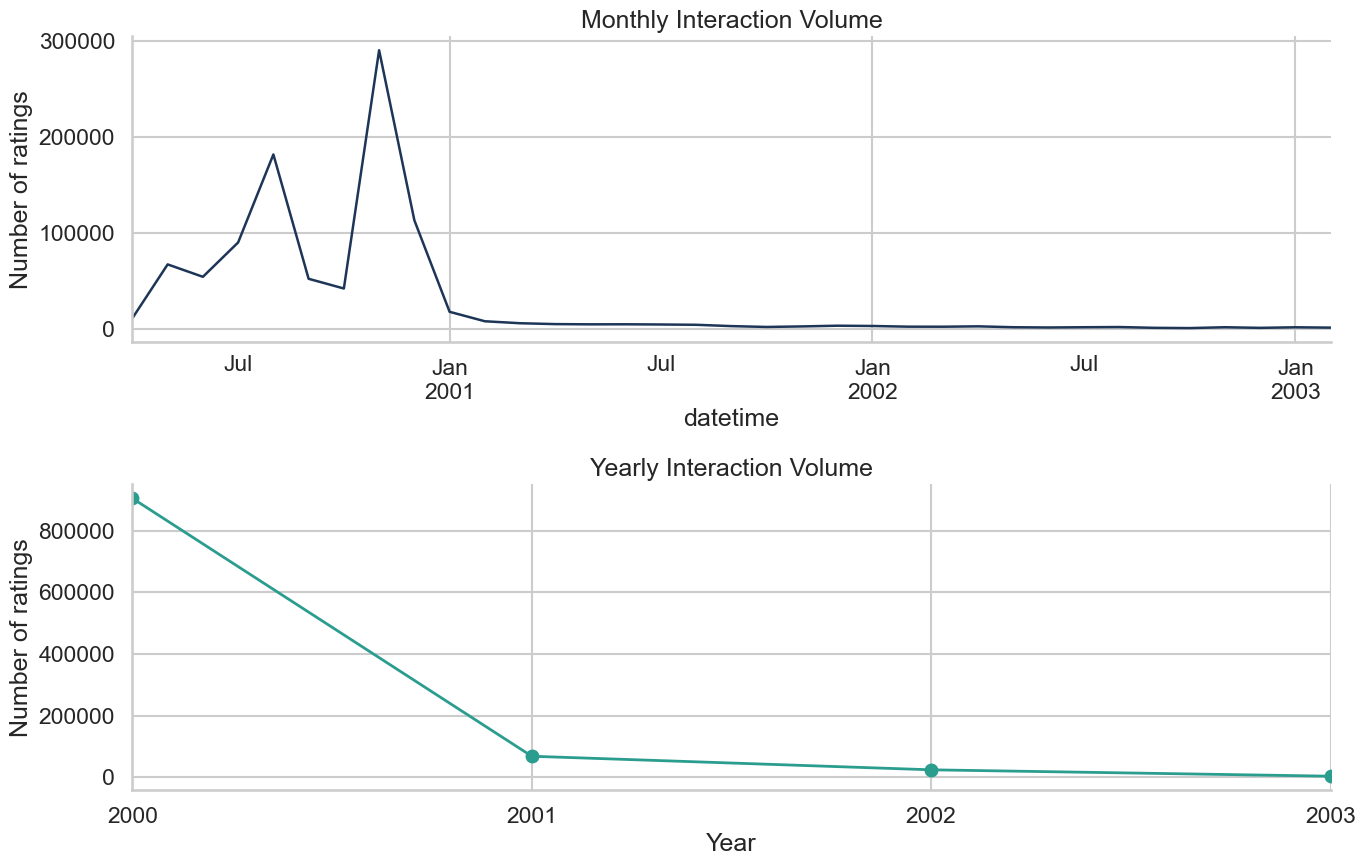


### Temporal implications for evaluation

- Ratings span from **2000-04-25 23:05:32** to **2003-02-28 17:49:50** (about **2.84** years).
- Monthly and yearly interaction volumes show clear temporal variation, suggesting that evaluation should respect time order.
- Based on observed dynamics, **time-based split is preferred over random split**.
- For production realism, use **temporal split** and consider **leave-last-N-out** per user to mimic forward-in-time recommendation.


In [20]:
ratings_ts = ratings.copy()
ratings_ts["datetime"] = pd.to_datetime(ratings_ts["timestamp"], unit="s", utc=True)
ratings_ts["datetime"] = ratings_ts["datetime"].dt.tz_convert(None)

min_dt = ratings_ts["datetime"].min()
max_dt = ratings_ts["datetime"].max()
span_days = (max_dt - min_dt).days
span_years = span_days / 365.25

monthly_counts = (
    ratings_ts.set_index("datetime")
    .resample("MS")
    .size()
    .rename("rating_count")
)

yearly_counts = (
    ratings_ts.set_index("datetime")
    .resample("YS")
    .size()
    .rename("rating_count")
)

yearly_mean_rating = (
    ratings_ts.set_index("datetime")
    .resample("YS")["rating"]
    .mean()
    .rename("avg_rating")
)

time_summary = pd.DataFrame(
    {
        "metric": [
            "Min timestamp",
            "Max timestamp",
            "Observed time span (days)",
            "Observed time span (years)",
            "Yearly volume coefficient of variation",
            "Yearly average-rating range",
        ],
        "value": [
            str(min_dt),
            str(max_dt),
            f"{span_days:,}",
            f"{span_years:.2f}",
            f"{(yearly_counts.std() / yearly_counts.mean()):.3f}",
            f"{(yearly_mean_rating.max() - yearly_mean_rating.min()):.3f}",
        ],
    }
)

display(time_summary)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
monthly_counts.plot(ax=axes[0], color="#1d3557", linewidth=1.8)
axes[0].set_title("Monthly Interaction Volume")
axes[0].set_ylabel("Number of ratings")

yearly_counts.plot(ax=axes[1], color="#2a9d8f", marker="o", linewidth=2)
axes[1].set_title("Yearly Interaction Volume")
axes[1].set_ylabel("Number of ratings")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()

yearly_volume_cv = float(yearly_counts.std() / yearly_counts.mean())
yearly_rating_shift = float(yearly_mean_rating.max() - yearly_mean_rating.min())

if span_years >= 2 and (yearly_volume_cv > 0.10 or yearly_rating_shift > 0.10):
    split_recommendation = "time-based split is preferred over random split"
else:
    split_recommendation = "random split can be acceptable, but time-based validation is still recommended for realism"

temporal_note = f"""
### Temporal implications for evaluation

- Ratings span from **{min_dt}** to **{max_dt}** (about **{span_years:.2f}** years).
- Monthly and yearly interaction volumes show clear temporal variation, suggesting that evaluation should respect time order.
- Based on observed dynamics, **{split_recommendation}**.
- For production realism, use **temporal split** and consider **leave-last-N-out** per user to mimic forward-in-time recommendation.
"""

display(Markdown(temporal_note))

## 7. Catalog Coverage and Activity Thresholds

This section quantifies light-activity segments to support threshold decisions, model robustness discussions, and catalog coverage expectations.

In [21]:
movie_lt_10_ratio = (ratings_per_movie < 10).mean()
movie_lt_20_ratio = (ratings_per_movie < 20).mean()
user_lt_50_ratio = (ratings_per_user < 50).mean()

coverage_thresholds = pd.DataFrame(
    {
        "metric": [
            "Movies with < 10 ratings",
            "Movies with < 20 ratings",
            "Users with < 50 ratings",
        ],
        "value": [
            f"{movie_lt_10_ratio:.2%}",
            f"{movie_lt_20_ratio:.2%}",
            f"{user_lt_50_ratio:.2%}",
        ],
    }
)

display(coverage_thresholds)

coverage_note = f"""
### Coverage and threshold implications

- **{movie_lt_10_ratio:.2%}** of movies have fewer than 10 ratings and **{movie_lt_20_ratio:.2%}** have fewer than 20 ratings.
- **{user_lt_50_ratio:.2%}** of users have fewer than 50 ratings.
- These ratios support using explicit activity thresholds in experiments (for robustness checks), and they highlight the practical challenge of maintaining strong catalog coverage for tail items.
"""

display(Markdown(coverage_note))

,metric,value
0,Movies with < 10 ratings,12.03%
1,Movies with < 20 ratings,17.89%
2,Users with < 50 ratings,28.86%



### Coverage and threshold implications

- **12.03%** of movies have fewer than 10 ratings and **17.89%** have fewer than 20 ratings.
- **28.86%** of users have fewer than 50 ratings.
- These ratios support using explicit activity thresholds in experiments (for robustness checks), and they highlight the practical challenge of maintaining strong catalog coverage for tail items.


## 8. EDA Conclusions

This section summarizes the key modeling implications in plain language: sparsity level, cold-start severity, distribution skew, temporal behavior, and why a popularity baseline is reasonable.

In [22]:
if sparsity >= 0.99:
    sparse_label = "extremely sparse"
elif sparsity >= 0.95:
    sparse_label = "very sparse"
elif sparsity >= 0.90:
    sparse_label = "sparse"
else:
    sparse_label = "moderately sparse"

if movie_head_20 >= 0.70:
    skew_label = "highly concentrated, with a very strong long-tail pattern"
elif movie_head_20 >= 0.55:
    skew_label = "clearly concentrated, with a pronounced long-tail pattern"
else:
    skew_label = "only moderately concentrated"

if cold_start_movie_ratio_5 >= 0.30 or cold_start_user_ratio_5 >= 0.30:
    cold_start_label = "significant"
elif cold_start_movie_ratio_5 >= 0.15 or cold_start_user_ratio_5 >= 0.15:
    cold_start_label = "moderate"
else:
    cold_start_label = "limited"

conclusion = f"""
### Key EDA conclusions

- The user–item matrix has a density of **{density:.2%}** and a sparsity of **{sparsity:.2%}**, indicating that the dataset is **{sparse_label}** and that most user–movie pairs remain unobserved.

- User-side cold-start is limited in this dataset partly because MovieLens 1M includes only users with at least 20 ratings. Cold-start appears **{cold_start_label}**: **{cold_start_user_ratio_5:.2%}** of users have at most 5 ratings, while **{cold_start_movie_ratio_5:.2%}** of movies have at most 5 ratings. This suggests that limited interaction history may affect model stability and personalization quality.

- Interaction activity is **{skew_label}**. In particular, the top 1% / 5% / 10% / 20% of movies account for **{movie_head_1:.2%} / {movie_head_5:.2%} / {movie_head_10:.2%} / {movie_head_20:.2%}** of all ratings, and the movie-popularity Gini coefficient is **{gini(movie_counts_sorted.values):.3f}**.

- These patterns justify using a popularity-based baseline: when data is sparse and concentrated in the head, a simple popularity model provides a robust benchmark and helps verify whether more complex models deliver genuine personalization gains.

- Based on the EDA, the dataset is sparse, popularity-skewed, and temporally structured. Therefore, we start with a popularity baseline, use time-aware evaluation where possible, and later compare against personalized models.
"""

display(Markdown(conclusion))


### Key EDA conclusions

- The user–item matrix has a density of **4.26%** and a sparsity of **95.74%**, indicating that the dataset is **very sparse** and that most user–movie pairs remain unobserved.

- User-side cold-start is limited in this dataset partly because MovieLens 1M includes only users with at least 20 ratings. Cold-start appears **limited**: **0.00%** of users have at most 5 ratings, while **8.88%** of movies have at most 5 ratings. This suggests that limited interaction history may affect model stability and personalization quality.

- Interaction activity is **clearly concentrated, with a pronounced long-tail pattern**. In particular, the top 1% / 5% / 10% / 20% of movies account for **8.91% / 28.38% / 44.45% / 65.21%** of all ratings, and the movie-popularity Gini coefficient is **0.634**.

- These patterns justify using a popularity-based baseline: when data is sparse and concentrated in the head, a simple popularity model provides a robust benchmark and helps verify whether more complex models deliver genuine personalization gains.

- Based on the EDA, the dataset is sparse, popularity-skewed, and temporally structured. Therefore, we start with a popularity baseline, use time-aware evaluation where possible, and later compare against personalized models.
